**ArcFace Face Recognition (Complete)**

This notebook:

Uses InsightFace ArcFace

Detects faces

Generates embeddings

Compares faces using cosine similarity

Ready for demo + collaboration

**1. Install Dependencies**

In [ ]:
!pip install -U insightface onnxruntime opencv-python matplotlib numpy


**2. Import Libraries**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from insightface.app import FaceAnalysis
from sklearn.metrics.pairwise import cosine_similarity

**3. Initialize ArcFace Model**

In [ ]:
# Initialize face analysis with ArcFace
app = FaceAnalysis(
    name="buffalo_l",        # ArcFace pretrained model
    providers=['CPUExecutionProvider']
)

app.prepare(ctx_id=0, det_size=(640, 640))


download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 83032.04KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


**4. Helper Function – Load & Show Image**

In [ ]:
def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def show_image(img, title="Image"):
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()


**5. Detect Face & Extract Embedding**

In [ ]:
def get_face_embedding(image):
    faces = app.get(image)

    if len(faces) == 0:
        raise ValueError("No face detected")

    # Take the largest face
    face = max(faces, key=lambda f: f.bbox[2] * f.bbox[3])
    embedding = face.normed_embedding

    return embedding, face


**6. Upload Images (Colab)**

In [ ]:
from google.colab import files

uploaded = files.upload()


**7. Extract Embeddings**

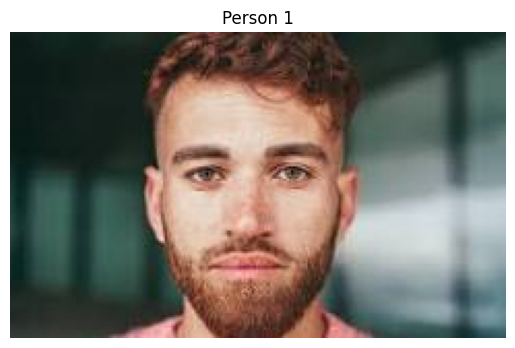

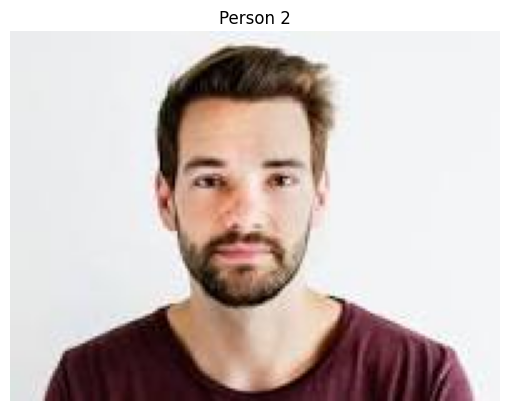

In [ ]:
img1 = load_image("/content/image_one_man.jpg")
img2 = load_image("/content/image_three_man.jpg")

emb1, face1 = get_face_embedding(img1)
emb2, face2 = get_face_embedding(img2)

show_image(img1, "Person 1")
show_image(img2, "Person 2")


**8. Face Similarity (Cosine Similarity)**

In [ ]:
similarity = cosine_similarity([emb1], [emb2])[0][0]

print(f"Cosine Similarity Score: {similarity:.4f}")


Cosine Similarity Score: -0.0233


**9. Decision Threshold**

In [ ]:
THRESHOLD = 0.5  # Typical ArcFace threshold

if similarity > THRESHOLD:
    print("Same Person")
else:
    print("Different Persons")

Different Persons
